In this notebook:
1. **Feature Engineering for Linear Logistic Regression**
2. **Feature Engineering for Polynomial Logistic Regression**
3. **Training and Testing Split of Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import talib as ta

from statsmodels.tsa.stattools import adfuller

In [2]:
data = pd.read_csv("../data/data.csv", index_col=0, parse_dates=True)
data.head()

,close,high,low,volume
Date,,,,
2023-01-03,1.843226,1.861658,1.824794,1624100
2023-01-04,1.834010,1.880091,1.834010,1706800
2023-01-05,1.834010,1.843226,1.824794,1391300
2023-01-06,1.880091,1.880091,1.834010,3364000
2023-01-09,1.898523,1.898523,1.880091,3771500


## 1 Feature Engineering for Linear Logistic Regression

- Defining target variable
- Defining base features
- Checking stationarity of features
- Removing highly correlated features

#### Target variable

We define the most important variable: *signal* which is the target of our classification ML model.  

First, we take the *close* price for each day and calculate its 1-day future return as $\frac{close_{t+1} - close_t}{close_t}$ and store it in a new column *future_1d_return*.  

Then for all 736 entries of our dataset, *signal* marks 1 if *future_1d_return* is positive or 0 otherwise (*future_1d_return* is negative or has no change).

In [3]:
# 'future_1d_return', 'signal' for Up or Down/No Change
data['future_1d_return'] = data['close'].pct_change().shift(-1)
data['signal'] = np.where(data['future_1d_return'] > 0, 1, 0)

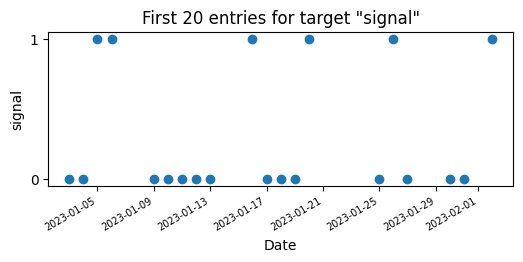

In [4]:
# plot the target 'signal'
plt.figure(figsize=(6,2))
plt.scatter(data.index[:20], data['signal'].iloc[:20])
plt.title('First 20 entries for target "signal"')
plt.ylabel('signal')
plt.xlabel('Date')
plt.yticks([0,1])
plt.xticks(rotation=30, ha='right', fontsize=7)
plt.show()

___

#### Base features

Currently, only price data *close*, *high*, *low* and volume data *volume* for each day are available for our ML model to train on to predict if *signal* is 1 or 0 (a prediction of 1 means the model predicts that the next day *close* will be higher than the current *close* and vice versa for the prediction of 0).

So, additional training features are engineered to increase the predictive power of our model.

Potential training features are derived from the primary price data of *close*, *high* and *low* columns for further considerations.

The engineered training features are:
- *pct_change_1d*, the change of the closing price from 1 day ago
- *pct_change_5d*, the change of the closing price from 5 days ago
- *rsi*, determines a numerical value for how overbought or oversold an asset is from the last *p* period
- *adx*, a directionless quantity that measures the intensity of a trend from the last *p* period
- *sma*, the simple moving average or the average price of an asset over the last *p* period
- *corr*, a single correlation value describing how *close* and *sma* is moving in relation to each other over the last *p* period. Measured on a scale from -1 to +1
- *volatility*, the percentage standard deviation of *pct_change_1d* over the last *p* period

In [5]:
# pct_change_1d, pct_change_5d, rsi, adx, volatility

data['pct_change_1d'] = data['close'].pct_change()
data['pct_change_5d'] = data['close'].pct_change(5)

p = 10 # period from the last two weeks: 10. 1 week has 10 trading days.
data['rsi'] = ta.RSI(data['close'], timeperiod=p)
data['adx'] = ta.ADX(data['high'], data['low'], data['close'], timeperiod=p)

data['sma'] = data['close'].rolling(window=p).mean()
data['corr'] = data['close'].rolling(window=p).corr(data['sma'])

data['volatility'] = data['pct_change_1d'].rolling(window=p, min_periods=p).std() * 100

print(f"Columns: {data.columns}")
print(f"\nLength of 'future_1d_return': {len(data['future_1d_return'])}, \
      Length of '1's' (Up signals): {len(data[data['signal'] == 1])}")

print(f"Length of data: {data.shape}")
data.dropna(inplace=True)
print(f"Length of data after dropping NaN values: {data.shape}")

Columns: Index(['close', 'high', 'low', 'volume', 'future_1d_return', 'signal',
       'pct_change_1d', 'pct_change_5d', 'rsi', 'adx', 'sma', 'corr',
       'volatility'],
      dtype='str')

Length of 'future_1d_return': 736,       Length of '1's' (Up signals): 295
Length of data: (736, 13)
Length of data after dropping NaN values: (716, 13)


From above, a total of 296 out of 736 entries (40%~) contain an 'Up'/'1' signal or a positive *future_1d_return*.

The final length of our dataset dropped from 736 to 716 entries after dropping the NaN values from feature engineering.

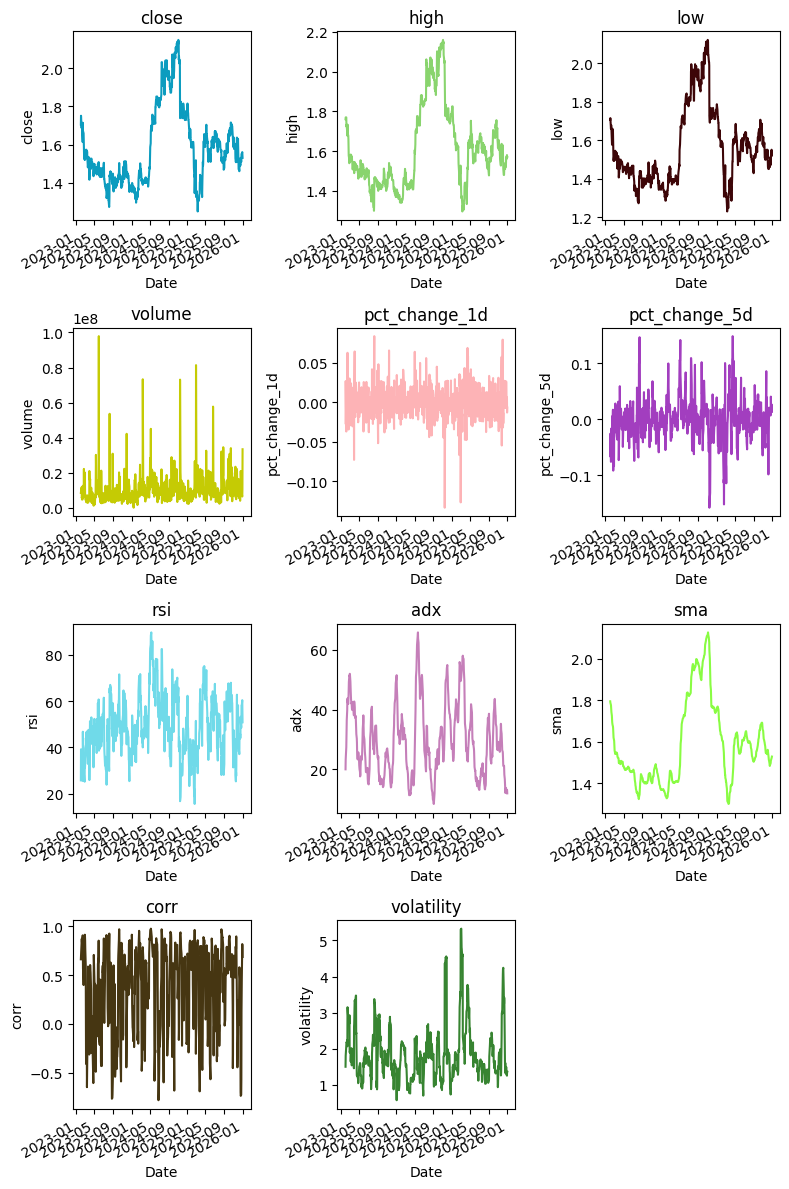

In [6]:
# plot all training features for further consideration
features = ['close', 'high', 'low', 'volume', 'pct_change_1d', 'pct_change_5d',
            'rsi', 'adx', 'sma', 'corr', 'volatility']
target = 'signal'

X = data[features].copy()

y = data[target].copy()

ncolumns = 3
nrows = (X.shape[1] + ncolumns-1) // ncolumns

i=1
for feature in X.columns:
    plt.subplot(nrows, ncolumns, i)

    X[feature].plot(figsize=(8, 12),color=np.random.rand(3))
    plt.ylabel(feature)
    plt.title(feature)
    i += 1

plt.tight_layout()
plt.show()

___
#### Check features for stationarity

Drop non-stationary features.

Non-stationary features would not enable us to use statistical properties to predict future forecasts.

In [7]:
def check_stationarity(series):
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")

    if result[1] <= 0.05:
        print(f"{series.name} is stationary. Null hypothesis rejected")
        return "stationary"
    else:
        print(f"{series.name} is non-stationary. Failed to reject null hypothesis")
        return "non-stationary"

In [8]:
# Check features for stationarity and drop non-stationary features

ls = []
for column in X.columns:
    if check_stationarity(X[column]) == "non-stationary":
        ls.append(column)
        X.drop(columns=[column], inplace=True)
    print()

print(f"Dropped features: {ls}")

ADF Statistic: -2.002683465454492
p-value: 0.28539773404388646
close is non-stationary. Failed to reject null hypothesis

ADF Statistic: -1.8322075815963075
p-value: 0.3645927798568976
high is non-stationary. Failed to reject null hypothesis

ADF Statistic: -1.9602767600070148
p-value: 0.3042572167495504
low is non-stationary. Failed to reject null hypothesis

ADF Statistic: -7.933609505603054
p-value: 3.4603143993301803e-12
volume is stationary. Null hypothesis rejected

ADF Statistic: -30.109254204156073
p-value: 0.0
pct_change_1d is stationary. Null hypothesis rejected

ADF Statistic: -4.785467975544041
p-value: 5.7976221403674354e-05
pct_change_5d is stationary. Null hypothesis rejected

ADF Statistic: -5.633128361520272
p-value: 1.0780847675957367e-06
rsi is stationary. Null hypothesis rejected

ADF Statistic: -4.787867587342451
p-value: 5.7368095043967166e-05
adx is stationary. Null hypothesis rejected

ADF Statistic: -1.5031528767994242
p-value: 0.531951083243281
sma is non-stat

*close*, *high*, *low* and *sma* were found to be non-stationary and thus are features that would not be viable for time-series forecasting and therefore dropped as training features.
___

#### Calculate the correlation between training features  
Drop features with correlation above an arbitrary threshold (0.7) with other features.

Training features with high correlation leads to a higher probability of **multicollinearity** occuring which is a situation where the learned parameters or coefficients of a regression model are unstable. A slight change in training data may cause the parameters to vary wildly, which makes the true relationship between the independent variables and the dependent variable harder to distinguish or interpret, making the model unreliable for prediction.

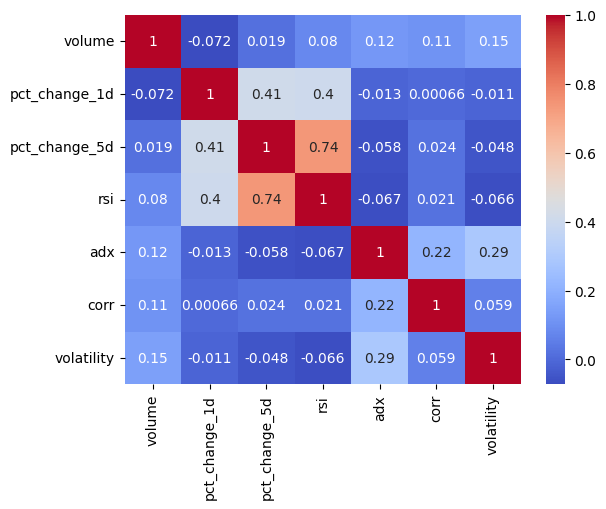

In [9]:
# plot a correlation matrix for features
import seaborn as sns

plt.figure()
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.show()

In [10]:
# Drop 'pct_change_5d' due to correlation of 0.74 with rsi
X.drop(columns=['pct_change_5d'], inplace=True)

In [11]:
# Final training features

list(X.columns)

['volume', 'pct_change_1d', 'rsi', 'adx', 'corr', 'volatility']

The final training features for the linear logistic regression model are
- *volume*, *pct_change_1d*, *rsi*, *adx*, *corr* and *volatility*.

In [12]:
# Add closing price to features for strategy evaluation later
X = pd.concat([data['close'].copy(), X], axis=1)
X.head()

,close,volume,pct_change_1d,rsi,adx,corr,volatility
Date,,,,,,,
2023-02-02,1.704984,8523200,-0.026316,25.717281,20.037760,0.662248,1.503273
2023-02-03,1.751065,9219400,0.027027,39.158319,23.303019,0.701775,1.806855
2023-02-07,1.686552,11662300,-0.036842,30.557358,27.483880,0.837258,2.094661
2023-02-08,1.704984,5665300,0.010929,35.083899,31.246655,0.872249,2.160632
2023-02-09,1.714200,6074700,0.005405,37.352538,33.786894,0.837857,2.182702


___
## 2 Feature engineering for polynomial logistic regression

- Manual implementation of polynomial feature engineering in Numpy
- Check manual implementation against Scikit-learn's implementation

#### Manual implementation of polynomial feature engineering in Numpy

A polynomial logistic regression model of degree 2 is selected for simplicity. The squared terms and interaction terms from the base features of the linear logistic regression model are manually calculated here.

Then, it is compared with Scikit-learn's implementation.

In [13]:
squared_terms = (X.drop(columns=['close']) ** 2).rename(columns={'volume':'volume^2', 'pct_change_1d':'pct_change_1d^2', 'rsi':'rsi^2',
                                       'adx':'adx^2', 'corr':'corr^2', 'volatility':'volatility^2'})

interaction_terms = pd.DataFrame(index=X.index)

cols_int_terms = [
    'volume*pct_change_1d', 'volume*rsi', 'volume*adx', 'volume*corr', 'volume*volatility',
    'pct_change_1d*rsi', 'pct_change_1d*adx', 'pct_change_1d*corr', 'pct_change_1d*volatility',
    'rsi*adx', 'rsi*corr', 'rsi*volatility', 'adx*corr', 'adx*volatility', 'corr*volatility'
]

for term in cols_int_terms:
    # Split the string by '*' to get the two feature names
    feat_a, feat_b = term.split('*')
    interaction_terms[term] = X[feat_a] * X[feat_b]

X_poly = pd.concat([X, squared_terms, interaction_terms], axis=1)

features2 = ['volume', 'rsi', 'adx', 'pct_change_1d', 'corr', 'volatility',
             'volume^2', 'rsi^2', 'adx^2', 'pct_change_1d^2', 'corr^2', 'volatility^2',
             'volume*pct_change_1d', 'volume*rsi', 'volume*adx', 'volume*corr', 'volume*volatility',
             'pct_change_1d*rsi', 'pct_change_1d*adx', 'pct_change_1d*corr', 'pct_change_1d*volatility',
             'rsi*adx', 'rsi*corr', 'rsi*volatility', 'adx*corr', 'adx*volatility', 'corr*volatility']

The final count of the training features for the polynomial regression model is 27 features.

#### Check manual polynomial feature engineering implementation against scikit-learn's function

In [14]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_tmp = poly.fit_transform(X.drop(columns=['close']))

X_poly_tmp = pd.DataFrame(
    X_poly_tmp, 
    columns=poly.get_feature_names_out(),
    index=X.index
)
X_poly_tmp['close'] = X['close']

In [15]:
# test to see if manual function output matches scikit-learn's feature mapping function's output

print(f"Manual shape: {X_poly.shape}")
print(f"Sklearn shape: {X_poly_tmp.shape}\n")

## Gemini generated
# --- Start ---
# Sort both DataFrames by column names so order doesn't matter
df_manual_sorted = X_poly.reindex(sorted(X_poly.columns), axis=1)
df_sklearn_sorted = X_poly_tmp.reindex(sorted(X_poly_tmp.columns), axis=1)

# Check if the set of column names is even the same
if set(df_manual_sorted.columns) != set(df_sklearn_sorted.columns):
    print("Warning: The column names do not match!")
    print(f"Missing in Sklearn: {set(df_manual_sorted.columns) - set(df_sklearn_sorted.columns)}")
    print(f"Missing in Manual: {set(df_sklearn_sorted.columns) - set(df_manual_sorted.columns)}")

# Compare only the raw numbers (ignoring headers/index)
are_math_identical = np.allclose(df_manual_sorted.values, df_sklearn_sorted.values, atol=1e-8)

print(f"Is the math identical? {are_math_identical}")
## --- End ---

Manual shape: (716, 28)
Sklearn shape: (716, 28)

Missing in Sklearn: {'adx*volatility', 'volume*corr', 'volume*adx', 'volume*pct_change_1d', 'rsi*volatility', 'adx*corr', 'volume*volatility', 'rsi*corr', 'volume*rsi', 'pct_change_1d*volatility', 'rsi*adx', 'pct_change_1d*rsi', 'pct_change_1d*corr', 'pct_change_1d*adx', 'corr*volatility'}
Missing in Manual: {'rsi corr', 'pct_change_1d volatility', 'volume corr', 'adx corr', 'pct_change_1d rsi', 'pct_change_1d adx', 'rsi volatility', 'volume volatility', 'volume pct_change_1d', 'volume adx', 'corr volatility', 'rsi adx', 'adx volatility', 'pct_change_1d corr', 'volume rsi'}
Is the math identical? True


The manual implementation and Scikit-learn implementation of feature engineering are the same. If not convinced, checking for yourself is encouraged.
___

## 3 Training and Testing Set Split

Splitting the dataset for both the linear logistic regression model and the polynomial logistic regression model into a training set and a testing set with a 80:20 split.

The important thing to note here is to make sure that the train-test split does not shuffle the data as order is important in timeseries data to prevent data leakage.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False) # no random shuffling for timeseries data
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(X_poly, y, test_size=0.20, shuffle=False)

print(f"Shape of\nX: {X.shape}, y: {y.shape}\nX_train: {X_train.shape}, X_poly_train: {X_poly_train.shape}, "
      f"y_train: {y_train.shape}, y_poly_train: {y_poly_train.shape}\nX_test : {X_test.shape}, "
      f"X_poly_test : {X_poly_test.shape}, y_test : {y_test.shape}, y_poly_test : {y_poly_test.shape}")

Shape of
X: (716, 7), y: (716,)
X_train: (572, 7), X_poly_train: (572, 28), y_train: (572,), y_poly_train: (572,)
X_test : (144, 7), X_poly_test : (144, 28), y_test : (144,), y_poly_test : (144,)


Save 2 pairs of data: 
- linear logistic regression: '*train_set*', '*test_set*'
- polynomial logistic regression: '*train_poly_set*', '*test_poly_set*'

In [17]:
# Combine feature set and target together

train_set = pd.concat([X_train, y_train], axis=1)
test_set = pd.concat([X_test, y_test], axis=1)

train_poly_set = pd.concat([X_poly_train, y_poly_train], axis=1)
test_poly_set = pd.concat([X_poly_test, y_poly_test], axis=1)

In [18]:
# Save training set and test set for model training

train_set.to_csv("../data/linear/train_set.csv")
test_set.to_csv("../data/linear/test_set.csv")

train_poly_set.to_csv("../data/poly/train_poly_set.csv")
test_poly_set.to_csv("../data/poly/test_poly_set.csv")